# Proyek UAS Mata Kuliah Kecerdasan Buatan Training dataset Bahasa Isyarat menggunakan CNN+LSTM
Kelompok Rabu-4:
- Nama (NPM) 
- Nama (NPM) 
- Nama (NPM) 
- Nama (NPM) 

# 1. Import Dependency

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sklearn
import tensorflow as tf
import os
import cv2
import time

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


I0000 00:00:1779537698.599305  356667 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1.1. Setting Tensorflow GPU

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Setup Open CV dan Mediapipe HandLanmarker

## 2.1. Inisialisasi Mediapipe HandLandmarker

In [3]:
# BaseOptions = mp.tasks.BaseOptions
# HandLandmarker = mp.tasks.vision.HandLandmarker
# HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
# VisionRunningMode = mp.tasks.vision.RunningMode

In [4]:
# options = HandLandmarkerOptions(
#     base_options=BaseOptions(model_asset_path='handlandmarker/hand_landmarker.task',
#                              delegate=BaseOptions.Delegate.GPU),
#     running_mode=VisionRunningMode.IMAGE,
#     num_hands=2) 

In [5]:
# def mediapipe_detection(image, model):
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     image.flags.writeable = False
#     results = model.detect(image)
#     image.flags.writeable = True
#     image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
#     return image, results

## 2.2. Inisialisasi OpenCV 2

In [6]:
# cap = cv2.VideoCapture(0, cv2.CAP_V4L2) # Setting Capture untuk di linux

# if not cap.isOpened():
#     print("Cannot open camera")
# else:
#     while cap.isOpened():

#         # membaca feed
#         ret, frame = cap.read()
        
#         if not ret or frame is None:
#             print("Camera/Frame error.")
#             break

#         # show feed
#         cv2.imshow('OpenCV Feed', frame)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break
# cap.release()
# cv2.destroyAllWindows()


# 3. Import Dataset

In [7]:
DATA_PATH = os.path.join('dataset')

# 4. Preprocessing Dataset

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from tensorflow.keras.optimizers import Adam

In [9]:
video_frames = 90

In [10]:
actions = np.array([name for name in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, name))])

label_map = {label:num for num, label in enumerate(actions)}

In [11]:
print("Daftar actions:", actions)
print("Label map:", label_map)

Daftar actions: ['Kita' 'Kamu' 'Siapa' 'Nunggu' 'Saya' 'Sudah' 'Hallo' 'Dimana'
 'Terima Kasih' 'Apa']
Label map: {np.str_('Kita'): 0, np.str_('Kamu'): 1, np.str_('Siapa'): 2, np.str_('Nunggu'): 3, np.str_('Saya'): 4, np.str_('Sudah'): 5, np.str_('Hallo'): 6, np.str_('Dimana'): 7, np.str_('Terima Kasih'): 8, np.str_('Apa'): 9}


## 4.1. Augmentasi Dataset

In [12]:
import numpy as np

def augment_sequence(sequence):
    augmented_sequences = []
    
    # 1. Jittering 1 (Noise kecil)
    noise1 = np.random.normal(0, 0.015, sequence.shape)
    augmented_sequences.append(sequence + noise1)
    
    # 2. Jittering 2 (Noise lebih besar)
    noise2 = np.random.normal(0, 0.025, sequence.shape)
    augmented_sequences.append(sequence + noise2)
    
    # 3. Scaling 1 (Pengecilan antara 0.85 sampai 0.95)
    scale_factor1 = np.random.uniform(0.85, 0.95)
    augmented_sequences.append(sequence * scale_factor1)
    
    # 4. Scaling 2 (Perbesaran antara 1.05 sampai 1.15)
    scale_factor2 = np.random.uniform(1.05, 1.15)
    augmented_sequences.append(sequence * scale_factor2)
    
    # 5. Kombinasi Jittering dan Scaling
    noise3 = np.random.normal(0, 0.02, sequence.shape)
    scale_factor3 = np.random.uniform(0.9, 1.1)
    seq_combo = (sequence + noise3) * scale_factor3
    augmented_sequences.append(seq_combo)
    
    # Total akan me-return 5 array augmentasi
    return augmented_sequences

In [13]:
sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    npy_files = [f for f in os.listdir(action_path) if f.endswith('.npy')]
    
    for npy_file in npy_files:
        res = np.load(os.path.join(action_path, npy_file))
        
        # Padding/Truncating ke "video_frames"
        if res.shape[0] < video_frames:
            pad_length = video_frames - res.shape[0]
            res = np.pad(res, ((0, pad_length), (0, 0)), mode='constant')
        else:
            res = res[:video_frames, :]
            
        # 1. Tambahkan data original terlebih dahulu
        sequences.append(res)
        labels.append(label_map[action])
        
        # 2. Opsional: Lakukan Augmentasi dan tambahkan data buatan ke dalam urutan list
        # Hati-hati: Melakukan augmentasi pada semua data akan melipatgandakan jumlah data dan RAM secara drastis
        aug_data = augment_sequence(res)
        for aug_res in aug_data:
            sequences.append(aug_res)
            labels.append(label_map[action])


In [14]:
np.array(sequences).shape

(3600, 90, 126)

In [15]:
np.array(labels).shape

(3600,)

In [16]:
print("Jumlah data sequences:", len(sequences))
print("Jumlah data labels:", len(labels))

Jumlah data sequences: 3600
Jumlah data labels: 3600


In [17]:
x = np.array(sequences)
y = to_categorical(labels).astype(int)
print("Shape x:", x.shape)
print("Shape y:", y.shape)

Shape x: (3600, 90, 126)
Shape y: (3600, 10)


In [18]:
x.shape

(3600, 90, 126)

In [19]:
# split train 60%, dev 20%, test 20%
X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

X_train, X_dev, y_train, y_dev = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("Shape of X_train:", X_train.shape)   # 60% data
print("Shape of y_train:", y_train.shape)

print("Shape of X_dev:", X_dev.shape)       # 20% data
print("Shape of y_dev:", y_dev.shape)

print("Shape of X_test:", X_test.shape)     # 20% data
print("Shape of y_test:", y_test.shape)

Shape of X_train: (2160, 90, 126)
Shape of y_train: (2160, 10)
Shape of X_dev: (720, 90, 126)
Shape of y_dev: (720, 10)
Shape of X_test: (720, 90, 126)
Shape of y_test: (720, 10)


# 5. Training Base Model

In [20]:
# 1. Definisikan Arsitektur CNN + LSTM
model = Sequential()

model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(90, 126)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

# LSTM Layers (untuk mempelajari Temporal/Sequence pergerakan titik waktu)
model.add(LSTM(64, return_sequences=True, activation='relu', recurrent_dropout=0.2))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=True, activation='relu', recurrent_dropout=0.2))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False, activation='relu', recurrent_dropout=0.2))


# Dense Layers (Klasifikasi akhir)
num_classes = len(actions)
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

opt = Adam(learning_rate=0.001)
# Compile Model
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model.summary()


/home/izzanns/GitHub_Repo/CNN_LSTM_SignLanguageModel/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779537702.902329  356667 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5230 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 90, 64)         │        24,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 45, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 22, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 22, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,250 (555.66 KB)

 Trainable params: 142,250 (555.66 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
log_dir = os.path.join('Logs')
os.makedirs(log_dir, exist_ok=True)

tb_callback = TensorBoard(log_dir=log_dir)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train, 
    y_train, 
    validation_data=(X_dev, y_dev), 
    epochs=150,
    batch_size=32,
    callbacks=[tb_callback, early_stopping]
)

Epoch 1/150


I0000 00:00:1779537709.410132  356763 service.cc:153] XLA service 0x63213c79b010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779537709.410145  356763 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070 Ti, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779537709.534088  356763 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779537710.444255  356763 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779537711.017124  356763 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_7039_rewritten_const_0_rearrange_0__.21.clone.clone.clone.clone.clone.sunk.clone.clone
I0000 00:00:1779537711.017281  356763 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_7039_grad_7409_const_0__.46.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:

 9/68 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.0798 - loss: 2.2979 

I0000 00:00:1779537723.783204  356763 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.1159 - loss: 2.2638

I0000 00:00:1779537726.147275  356762 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_7039_rewritten_const_0_rearrange_0__.21.clone.clone.clone.clone.clone.sunk.clone.clone
I0000 00:00:1779537726.147463  356762 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_7039_grad_7409_const_0__.46.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779537726.147660  356762 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_6674_grad_8204_const_0__.55.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779537726.147876  356762 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_6309_grad_8998_const_0__.64.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779537726.148078  356762 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_6309_rewritten_const_0_rearrange_0__.11.clone.clone.clone.clone.clone.sunk.clone.clone.clone
I0000 00:00:1779537

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - categorical_accuracy: 0.1166 - loss: 2.2632

I0000 00:00:1779537736.800496  356764 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_11882_const_0__.11.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779537736.800702  356764 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_12201_const_0__.16.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779537736.800842  356764 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_12520_const_0__.21.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779537736.819950  356764 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779537737.450415  357425 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_24', 12 bytes spill stores, 

68/68 ━━━━━━━━━━━━━━━━━━━━ 36s 248ms/step - categorical_accuracy: 0.1639 - loss: 2.2230 - val_categorical_accuracy: 0.2292 - val_loss: 2.0743
Epoch 2/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - categorical_accuracy: 0.2120 - loss: 2.0701 - val_categorical_accuracy: 0.1972 - val_loss: 2.0820
Epoch 3/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - categorical_accuracy: 0.2148 - loss: 2.0787 - val_categorical_accuracy: 0.2139 - val_loss: 2.0182
Epoch 4/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - categorical_accuracy: 0.2292 - loss: 2.0015 - val_categorical_accuracy: 0.2514 - val_loss: 1.9310
Epoch 5/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - categorical_accuracy: 0.2537 - loss: 1.9955 - val_categorical_accuracy: 0.2972 - val_loss: 1.8696
Epoch 6/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - categorical_accuracy: 0.2935 - loss: 1.8234 - val_categorical_accuracy: 0.3042 - val_loss: 1.8229
Epoch 7/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - categorical_accuracy: 0.3287 - loss: 1.7110 

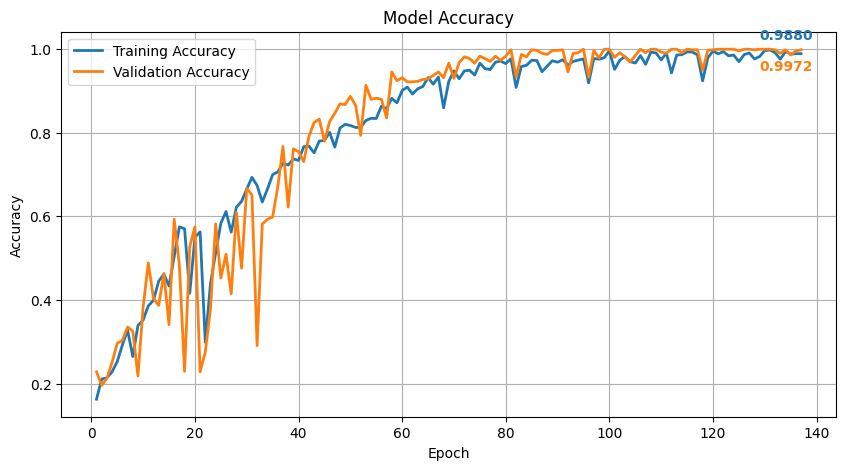

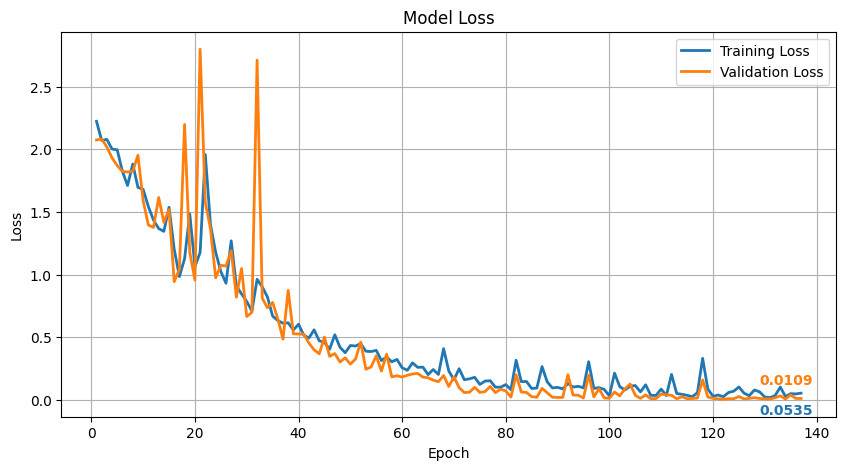

Final Training Accuracy:  0.9880
Final Validation Accuracy: 0.9972
Final Training Loss:       0.0535
Final Validation Loss:     0.0109


In [22]:
acc = history.history['categorical_accuracy']
val_acc = history.history['val_categorical_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Model Accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', linewidth=2)

# Anotasi hasil metrik di akhir plot akurasi
# C0 = Default Blue, C1 = Default Orange
plt.annotate(f'{acc[-1]:.4f}', xy=(epochs[-1], acc[-1]), xytext=(-30, 10), textcoords='offset points', color='C0', fontweight='bold')
plt.annotate(f'{val_acc[-1]:.4f}', xy=(epochs[-1], val_acc[-1]), xytext=(-30, -15), textcoords='offset points', color='C1', fontweight='bold')

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)  # Menambahkan background bergaris
plt.show()

# Plot Model Loss
plt.figure(figsize=(10,5))
plt.plot(epochs, loss, label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)

# Anotasi hasil metrik di akhir plot loss
plt.annotate(f'{loss[-1]:.4f}', xy=(epochs[-1], loss[-1]), xytext=(-30, -15), textcoords='offset points', color='C0', fontweight='bold')
plt.annotate(f'{val_loss[-1]:.4f}', xy=(epochs[-1], val_loss[-1]), xytext=(-30, 10), textcoords='offset points', color='C1', fontweight='bold')

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)  # Menambahkan background bergaris
plt.show()

print(f"Final Training Accuracy:  {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Final Training Loss:       {loss[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss[-1]:.4f}")

I0000 00:00:1779537876.345848  356763 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_152860_const_0__.9.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779537876.346053  356763 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_153175_const_0__.14.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779537876.346237  356763 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_153490_const_0__.19.clone.clone.clone.clone.clone.sunk.clone


 1/23 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step

I0000 00:00:1779537877.959352  356763 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_153966_const_0__.9.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779537877.959571  356763 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_154285_const_0__.14.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779537877.959731  356763 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_154604_const_0__.19.clone.clone.clone.clone.clone.sunk.clone


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step
================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

        Kita       1.00      1.00      1.00        93
        Kamu       1.00      1.00      1.00        73
       Siapa       1.00      1.00      1.00        79
      Nunggu       0.98      1.00      0.99        59
        Saya       1.00      0.94      0.97        81
       Sudah       0.94      1.00      0.97        63
       Hallo       1.00      1.00      1.00        68
      Dimana       1.00      1.00      1.00        69
Terima Kasih       1.00      1.00      1.00        68
         Apa       1.00      1.00      1.00        67

    accuracy                           0.99       720
   macro avg       0.99      0.99      0.99       720
weighted avg       0.99      0.99      0.99       720



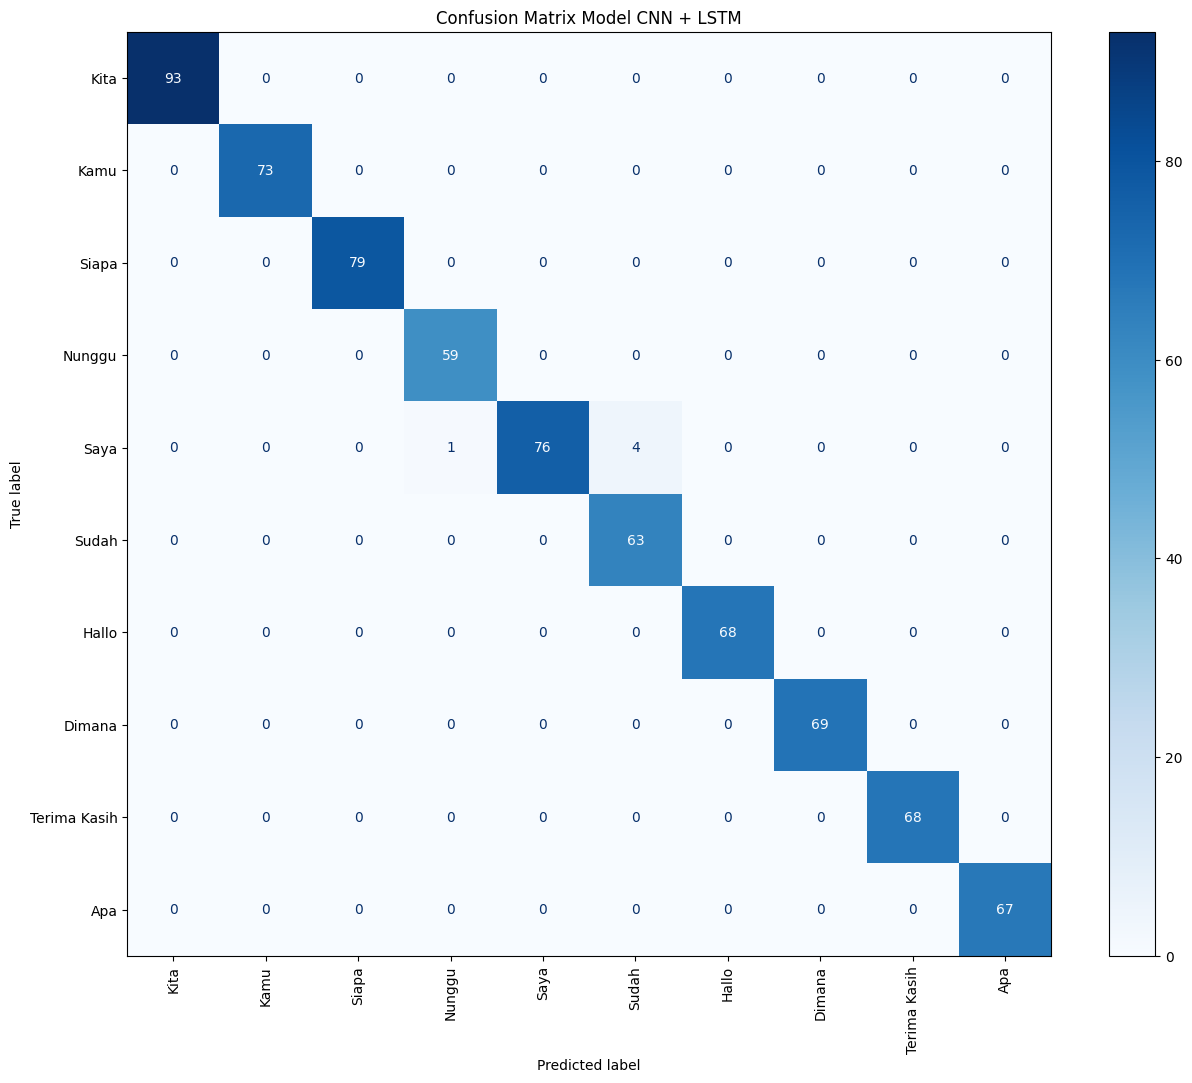

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Lakukan prediksi pada data pengujian (X_test)
y_pred = model.predict(X_test)

# 2. Konversi hasil probabilitas/one-hot ke label indeks integer (0-25 untuk A-Z)
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Tambahkan argumen labels untuk memastikan semua 26 kelas (0 s.d 25) terhitung
label_indices = np.arange(len(actions))

# 3. Menampilkan Metrik Utama: Precision, Recall, F1-Score
print("================ CLASSIFICATION REPORT ================")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    labels=label_indices, 
    target_names=actions, 
    zero_division=0
))

# 4. Mendapatkan Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=label_indices)

# 5. Visualisasi Confusion Matrix dengan Matplotlib & scikit-learn
fig, ax = plt.subplots(figsize=(15, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=actions)

# Menyesuaikan label dan colormap
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix Model CNN + LSTM')
plt.show()

In [24]:
print("Mengevaluasi model pada Test Set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("\n=== HASIL EVALUASI TEST SET ===")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({(test_accuracy*100):.2f}%)")

Mengevaluasi model pada Test Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - categorical_accuracy: 0.9931 - loss: 0.0123

=== HASIL EVALUASI TEST SET ===
Test Loss     : 0.0123
Test Accuracy : 0.9931 (99.31%)


In [ ]:
if not os.path.exists('base_model'):
    os.makedirs('base_model')
model.save('base_model/model_cnn_lstm_isyarat.keras')

# 6. Hyperparameter Tuning

## 6.1. Setup Tuner

In [26]:
import keras_tuner as kt

In [27]:
def build_model(hp):
    model = Sequential()
    
    # CNN 1
    hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=128, step=32)
    model.add(Conv1D(filters=hp_filters_1, kernel_size=3, activation='relu', padding='same', input_shape=(90, 126)))
    model.add(MaxPooling1D(pool_size=2))

    # Dropout 1
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_1))

    # CNN 2
    hp_filters_2 = hp.Int('filters_2', min_value=32, max_value=128, step=32)
    model.add(Conv1D(filters=hp_filters_2, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # Dropout 2
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_2))

    # LSTM 1
    hp_lstm_1 = hp.Int('lstm_1', min_value=32, max_value=128, step=32)
    hp_lstm_1_recurrent_dropout = hp.Float('lstm_1_recurrent_dropout', min_value=0.1, max_value=0.3, step=0.1)
    model.add(LSTM(hp_lstm_1, return_sequences=True, activation='relu', recurrent_dropout=hp_lstm_1_recurrent_dropout))

    # Dropout 3
    hp_dropout_3 = hp.Float('dropout_3', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_3))

    # LSTM 2
    hp_lstm_2 = hp.Int('lstm_2', min_value=32, max_value=128, step=32)
    hp_lstm_2_recurrent_dropout = hp.Float('lstm_2_recurrent_dropout', min_value=0.1, max_value=0.3, step=0.1)
    model.add(LSTM(hp_lstm_2, return_sequences=True, activation='relu', recurrent_dropout=hp_lstm_2_recurrent_dropout))
    
    # Dropout 4
    hp_dropout_4 = hp.Float('dropout_4', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_4))

    # LSTM 3
    hp_lstm_3 = hp.Int('lstm_3', min_value=64, max_value=256, step=64)
    hp_lstm_3_recurrent_dropout = hp.Float('lstm_3_recurrent_dropout', min_value=0.1, max_value=0.3, step=0.1)
    model.add(LSTM(hp_lstm_3, return_sequences=False, activation='relu', recurrent_dropout=hp_lstm_3_recurrent_dropout))

    # Dropout 5
    hp_dropout_5 = hp.Float('dropout_5', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_5))

    # Dense 1
    hp_dense_1 = hp.Int('dense_1', min_value=32, max_value=128, step=32)
    model.add(Dense(hp_dense_1, activation='relu'))

    # Dropout 6    
    hp_dropout_6 = hp.Float('dropout_6', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_6))

    # Dense 2
    hp_dense_2 = hp.Int('dense_2', min_value=32, max_value=128, step=32)
    model.add(Dense(hp_dense_2, activation='relu'))

    model.add(Dense(num_classes, activation='softmax'))

    hp_learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    optimizer = Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['categorical_accuracy'])
        
    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_categorical_accuracy',
    # Ubah max_trials, semakin besar semakin optimal
    max_trials=50,
    executions_per_trial=1,
    directory='tuner_logs',
    project_name='cnn_lstm_sign_language'
)

Reloading Tuner from tuner_logs/cnn_lstm_sign_language/tuner0.json


## 6.2. Melakukan Hyperparameter Tuning

In [29]:
tuner.search_space_summary()

early_stopping_tuner = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

tuner.search(
    X_train, 
    y_train, 
    validation_data=(X_dev, y_dev), 
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping_tuner]
)

Search space summary
Default search space size: 17
filters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.3, 'step': 0.1, 'sampling': 'linear'}
filters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout_2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.3, 'step': 0.1, 'sampling': 'linear'}
lstm_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
lstm_1_recurrent_dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.3, 'step': 0.1, 'sampling': 'linear'}
dropout_3 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.3, 'step': 0.1, 'sampling': 'linear'}
lstm_2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value':

In [31]:

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
=== Pencarian Selesai! ===
Kombinasi Hyperparameter Terbaik Ditemukan:
- Filters Conv1D Pertama : {best_hps.get('filters_1')}
- Dropout 1              : {best_hps.get('dropout_1')}
- Filters Conv1D Kedua   : {best_hps.get('filters_2')}
- Dropout 2              : {best_hps.get('dropout_2')}
- Units LSTM Pertama     : {best_hps.get('lstm_1')}
- Dropout LSTM Pertama   : {best_hps.get('lstm_1_recurrent_dropout')}
- Dropout 3              : {best_hps.get('dropout_3')}
- Units LSTM Kedua       : {best_hps.get('lstm_2')}
- Dropout LSTM Kedua     : {best_hps.get('lstm_2_recurrent_dropout')}
- Dropout 4              : {best_hps.get('dropout_4')}
- Units LSTM Ketiga      : {best_hps.get('lstm_3')}
- Dropout LSTM Ketiga    : {best_hps.get('lstm_3_recurrent_dropout')}
- Dropout 5              : {best_hps.get('dropout_5')}
- Units Dense Pertama    : {best_hps.get('dense_1')}
- Dropout 6              : {best_hps.get('dropout_6')}
- Units Dense            : {best_hps.get('dense_2')}
- Learning Rate          : {best_hps.get('learning_rate')})
""")

best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


=== Pencarian Selesai! ===
Kombinasi Hyperparameter Terbaik Ditemukan:
- Filters Conv1D Pertama : 64
- Dropout 1              : 0.1
- Filters Conv1D Kedua   : 96
- Dropout 2              : 0.1
- Units LSTM Pertama     : 96
- Dropout LSTM Pertama   : 0.2
- Dropout 3              : 0.1
- Units LSTM Kedua       : 32
- Dropout LSTM Kedua     : 0.1
- Dropout 4              : 0.2
- Units LSTM Ketiga      : 128
- Dropout LSTM Ketiga    : 0.2
- Dropout 5              : 0.2
- Units Dense Pertama    : 32
- Dropout 6              : 0.1
- Units Dense            : 64
- Learning Rate          : 0.00023368356870813616)



/home/izzanns/GitHub_Repo/CNN_LSTM_SignLanguageModel/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/izzanns/GitHub_Repo/CNN_LSTM_SignLanguageModel/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 90, 64)         │        24,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 45, 96)         │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 22, 96)         │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 22, 32)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,730 (870.04 KB)

 Trainable params: 222,730 (870.04 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# 1. Dapatkan hyperparameters terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# 2. Bangun (build) ulang model dari hyperparameters terbaik
tuned_model = tuner.hypermodel.build(best_hps)

# 3. Lakukan training ulang (retrain) pada model tersebut untuk mendapatkan 'history'
print("Me-retrain model terbaik...")
history_tuned = tuned_model.fit(
    X_train, 
    y_train, 
    validation_data=(X_dev, y_dev), 
    epochs=150, # Gunakan jumlah epoch yang sama atau lebih
    batch_size=32,
    callbacks=[early_stopping_tuner] # Gunakan callback yang sama
)

Me-retrain model terbaik...
Epoch 1/150


I0000 00:00:1779538220.863819  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_8_1_while_body_186613_rewritten_const_0_rearrange_0__.21.clone.clone.clone.clone.clone.sunk.clone.clone
I0000 00:00:1779538220.864018  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_8_1_while_body_186613_grad_186983_const_0__.46.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779538220.864218  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_7_1_while_body_186248_grad_187778_const_0__.55.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779538220.864409  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_6_1_while_body_185883_grad_188572_const_0__.64.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779538220.864595  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_6_1_while_body_185883_rewritten_const_0_rearrange_0__.11.clone.clone.clone.clone.clone.sunk.clone.c

66/68 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.1593 - loss: 2.2264

I0000 00:00:1779538230.691663  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_8_1_while_body_186613_rewritten_const_0_rearrange_0__.21.clone.clone.clone.clone.clone.sunk.clone.clone
I0000 00:00:1779538230.691861  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_8_1_while_body_186613_grad_186983_const_0__.46.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779538230.692071  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_7_1_while_body_186248_grad_187778_const_0__.55.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779538230.692265  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_6_1_while_body_185883_grad_188572_const_0__.64.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779538230.692456  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_6_1_while_body_185883_rewritten_const_0_rearrange_0__.11.clone.clone.clone.clone.clone.sunk.clone.c

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - categorical_accuracy: 0.1600 - loss: 2.2239

I0000 00:00:1779538238.802410  356765 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_6_1_while_body_190907_const_0__.11.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779538238.802578  356765 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_7_1_while_body_191226_const_0__.16.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779538238.802698  356765 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_8_1_while_body_191545_const_0__.21.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779538240.110606  356765 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_6_1_while_body_190907_const_0__.11.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779538240.110812  356765 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_7_1_while_body_191226_const_0__.16.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779538240.111019  356765 dot_merger.cc:481] Merging Dots in computation: sequ

68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 189ms/step - categorical_accuracy: 0.1833 - loss: 2.1418 - val_categorical_accuracy: 0.1944 - val_loss: 2.0603
Epoch 2/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - categorical_accuracy: 0.2005 - loss: 2.0467 - val_categorical_accuracy: 0.2236 - val_loss: 1.9840
Epoch 3/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.2116 - loss: 1.9865 - val_categorical_accuracy: 0.2222 - val_loss: 1.9558
Epoch 4/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.2361 - loss: 1.9324 - val_categorical_accuracy: 0.3347 - val_loss: 1.8696
Epoch 5/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - categorical_accuracy: 0.3005 - loss: 1.8732 - val_categorical_accuracy: 0.3722 - val_loss: 1.7599
Epoch 6/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - categorical_accuracy: 0.3551 - loss: 1.7709 - val_categorical_accuracy: 0.4431 - val_loss: 1.5964
Epoch 7/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - categorical_accuracy: 0.4194 - loss: 1.5437 

## 6.3. Analisis Model Terbaik Setelah Tuning

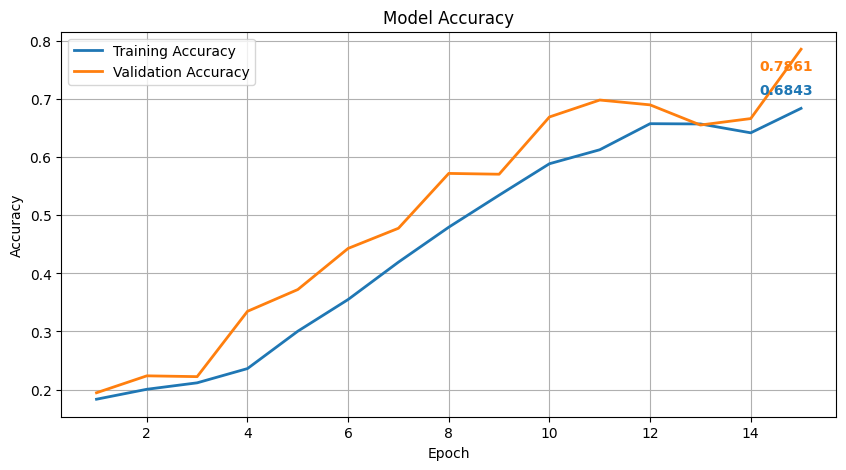

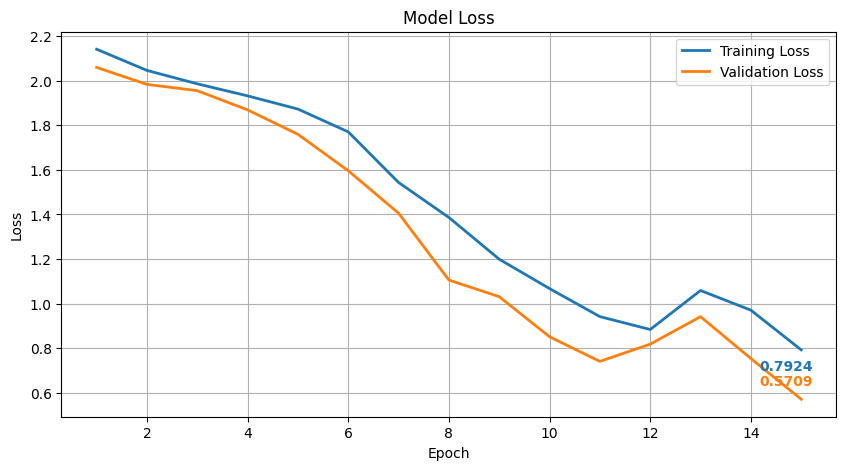

Final Training Accuracy:  0.6843
Final Validation Accuracy: 0.7861
Final Training Loss:       0.7924
Final Validation Loss:     0.5709


In [34]:
acc = history_tuned.history['categorical_accuracy']
val_acc = history_tuned.history['val_categorical_accuracy']
loss = history_tuned.history['loss']
val_loss = history_tuned.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Model Accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', linewidth=2)

# Anotasi hasil metrik di akhir plot akurasi
# C0 = Default Blue, C1 = Default Orange
plt.annotate(f'{acc[-1]:.4f}', xy=(epochs[-1], acc[-1]), xytext=(-30, 10), textcoords='offset points', color='C0', fontweight='bold')
plt.annotate(f'{val_acc[-1]:.4f}', xy=(epochs[-1], val_acc[-1]), xytext=(-30, -15), textcoords='offset points', color='C1', fontweight='bold')

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)  
plt.show()

# Plot Model Loss
plt.figure(figsize=(10,5))
plt.plot(epochs, loss, label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)

# Anotasi hasil metrik di akhir plot loss
plt.annotate(f'{loss[-1]:.4f}', xy=(epochs[-1], loss[-1]), xytext=(-30, -15), textcoords='offset points', color='C0', fontweight='bold')
plt.annotate(f'{val_loss[-1]:.4f}', xy=(epochs[-1], val_loss[-1]), xytext=(-30, 10), textcoords='offset points', color='C1', fontweight='bold')

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)  # Menambahkan background bergaris
plt.show()

print(f"Final Training Accuracy:  {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Final Training Loss:       {loss[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss[-1]:.4f}")

I0000 00:00:1779538366.374852  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_6_1_while_body_200135_const_0__.9.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779538366.375091  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_7_1_while_body_200450_const_0__.14.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779538366.375279  356764 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_8_1_while_body_200765_const_0__.19.clone.clone.clone.clone.clone.sunk.clone


 1/23 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step

I0000 00:00:1779538368.155338  356762 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_6_1_while_body_201241_const_0__.9.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779538368.155609  356762 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_7_1_while_body_201560_const_0__.14.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779538368.155729  356762 dot_merger.cc:481] Merging Dots in computation: sequential_2_1_lstm_8_1_while_body_201879_const_0__.19.clone.clone.clone.clone.clone.sunk.clone


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step
================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

        Kita       0.00      0.00      0.00        93
        Kamu       0.00      0.00      0.00        73
       Siapa       0.00      0.00      0.00        79
      Nunggu       0.00      0.00      0.00        59
        Saya       0.40      0.02      0.05        81
       Sudah       0.00      0.00      0.00        63
       Hallo       0.11      1.00      0.19        68
      Dimana       0.00      0.00      0.00        69
Terima Kasih       0.00      0.00      0.00        68
         Apa       0.97      1.00      0.99        67

    accuracy                           0.19       720
   macro avg       0.15      0.20      0.12       720
weighted avg       0.15      0.19      0.12       720



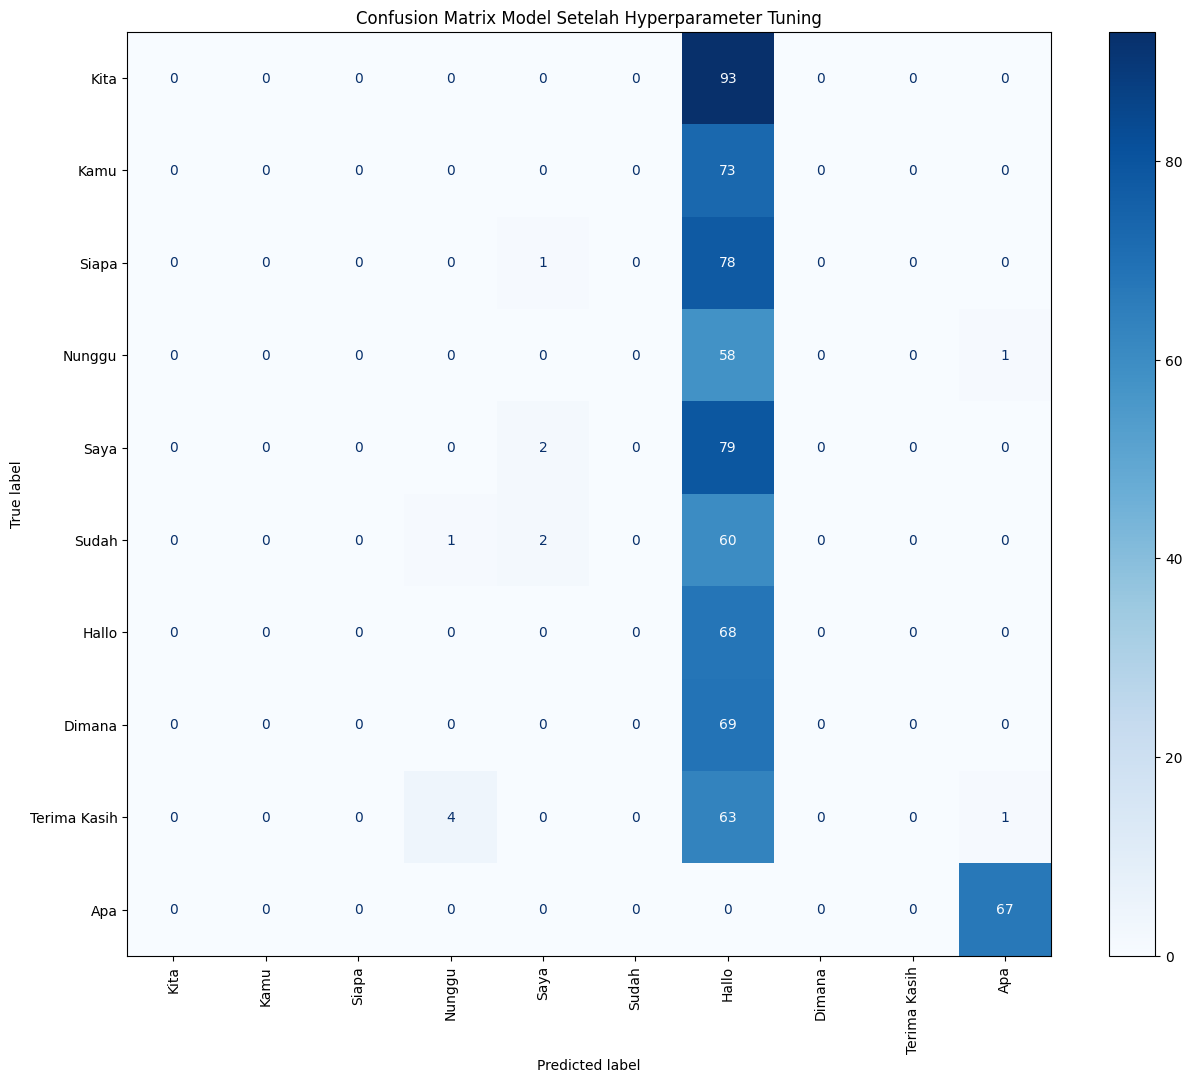

In [37]:
# 1. Lakukan prediksi pada data pengujian (X_test)
y_pred = tuned_model.predict(X_test)

y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Tambahkan argumen labels untuk memastikan semua 26 kelas (0 s.d 25) terhitung
label_indices = np.arange(len(actions))

# 3. Menampilkan Metrik Utama: Precision, Recall, F1-Score
print("================ CLASSIFICATION REPORT ================")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    labels=label_indices, 
    target_names=actions, 
    zero_division=0
))

# 4. Mendapatkan Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=label_indices)

# 5. Visualisasi Confusion Matrix dengan Matplotlib & scikit-learn
fig, ax = plt.subplots(figsize=(15, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=actions)

# Menyesuaikan label dan colormap
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix Model Setelah Hyperparameter Tuning')
plt.show()

In [38]:
print("Mengevaluasi model pada Test Set...")
test_loss, test_accuracy = tuned_model.evaluate(X_test, y_test, verbose=1)

print("\n=== HASIL EVALUASI TEST SET ===")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({(test_accuracy*100):.2f}%)")

Mengevaluasi model pada Test Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.1903 - loss: 2.0788

=== HASIL EVALUASI TEST SET ===
Test Loss     : 2.0788
Test Accuracy : 0.1903 (19.03%)


## 6.2. Simpan Model Terbaik

In [ ]:
if not os.path.exists('best_model'):
    os.makedirs('best_model')
best_model.save('best_model/model_cnn_lstm_isyarat.keras')